# Zachary's Karate Club Network

>In this Colab, we will write a full pipeline for **learning node embeddings**.
We will go through the following 3 steps.

>To start, we will load a classic graph in network science, the [Karate Club Network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). We will explore multiple graph statistics for that graph.

>We will then work together to transform the graph structure into a PyTorch tensor, so that we can perform machine learning over the graph.

>Finally, we will finish the first learning algorithm on graphs: a node embedding model. For simplicity, our model here is simpler than DeepWalk / node2vec algorithms taught in the lecture. But it's still rewarding and challenging, as we will write it from scratch via PyTorch.

>Now let's get started!
>
>**Note**: Make sure to **sequentially run all the cells**, so that the intermediate variables / packages will carry over to the next cell

# Graph Basics
To start, we will load a classic graph in network science, the [Karate Club Network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). We will explore multiple graph statistics for that graph.

## Setup
We will heavily use NetworkX in this Colab.

In [ ]:
import networkx as nx

## Zachary's karate club network

The [Karate Club Network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) is a graph describes a social network of 34 members of a karate club and documents links between members who interacted outside the club.

In [ ]:
G = nx.karate_club_graph()

# G is an undirected graph
type(G)

networkx.classes.graph.Graph

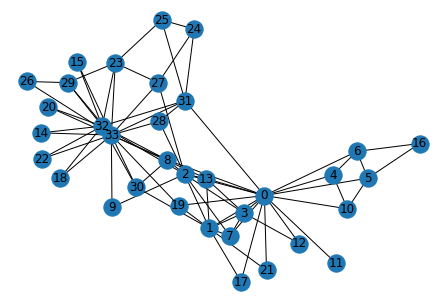

In [ ]:
# Visualize the graph
nx.draw(G, with_labels = True)

## Average degree of the karate club network

In [ ]:
print(sum(d for _, d in G.degree()) / len(G.degree))

4.588235294117647


In [ ]:
def average_degree(num_edges, num_nodes):

  avg_degree = round(2 * num_edges / num_nodes)

  return avg_degree

num_edges = G.number_of_edges()
num_nodes = G.number_of_nodes()

avg_degree = average_degree(num_edges, num_nodes)

print("Average degree of karate club network is {}".format(avg_degree))

Average degree of karate club network is 5


## Average clustering coefficient of the karate club network

In [ ]:
def average_clustering_coefficient(G):

  avg_cluster_coef = 0

  avg_cluster_coef = nx.average_clustering(G)
  avg_cluster_coef = round(avg_cluster_coef, 2)

  return avg_cluster_coef

avg_cluster_coef = average_clustering_coefficient(G)
print("Average clustering coefficient of karate club network is {}".format(avg_cluster_coef))

Average clustering coefficient of karate club network is 0.57


## PageRank value for node 0 (node with id 0) after one PageRank iteration

Implementing the PageRank equation: $r_j = \sum_{i \rightarrow j} \beta \frac{r_i}{d_i} + (1 - \beta) \frac{1}{N}$

In [ ]:
def one_iter_pagerank(G, beta, r0, node_id):

  r1 = 0

  r1 = beta * sum(r0 / G.degree[neighbor] for neighbor in G.neighbors(node_id))
  r1 += (1 - beta) / G.number_of_nodes()
  r1 = round(r1, 2)

  return r1

beta = 0.8
r0 = 1 / G.number_of_nodes()

node = 0
r1 = one_iter_pagerank(G, beta, r0, node)

print("The PageRank value for node 0 after one iteration is {}".format(r1))

The PageRank value for node 0 after one iteration is 0.13


## (Raw) closeness centrality for the karate club network node 5?

The equation for closeness centrality is $c(v) = \frac{1}{\sum_{u \neq v}\text{shortest path length between } u \text{ and } v}$

In [ ]:
def closeness_centrality(G, node=5):

  closeness = 0
  closeness = nx.closeness_centrality(G, u=node)
  closeness /= G.number_of_nodes() - 1
  closeness = round(closeness, 2)

  return closeness

node = 5
closeness = closeness_centrality(G, node=node)
print("The karate club network has closeness centrality {}".format(closeness))

The karate club network has closeness centrality 0.01


# Graph to Tensor
We will then work together to transform the graph $G$ into a PyTorch tensor, so that we can perform machine learning over the graph.

## Setup
Check if PyTorch is properly installed

In [ ]:
import torch
print(torch.__version__)

1.9.0+cu102


## PyTorch tensor basics

We can generate PyTorch tensor with all zeros, ones or random values.

In [ ]:
# Generate 3 x 4 tensor with all ones
ones = torch.ones(3, 4)
print(ones)

# Generate 3 x 4 tensor with all zeros
zeros = torch.zeros(3, 4)
print(zeros)

# Generate 3 x 4 tensor with random values on the interval [0, 1)
random_tensor = torch.rand(3, 4)
print(random_tensor)

# Get the shape of the tensor
print(ones.shape)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0.0776, 0.5386, 0.2703, 0.8241],
        [0.8090, 0.8454, 0.6076, 0.8433],
        [0.0848, 0.2351, 0.4120, 0.9219]])
torch.Size([3, 4])


PyTorch tensor contains elements for a single data type, the `dtype`.

In [ ]:
# Create a 3 x 4 tensor with all 32-bit floating point zeros
zeros = torch.zeros(3, 4, dtype=torch.float32)
print(zeros.dtype)

# Change the tensor dtype to 64-bit integer
zeros = zeros.type(torch.long)
print(zeros.dtype)

torch.float32
torch.int64


## Question 5: Getting the edge list of the karate club network and transform it into `torch.LongTensor`. What is the `torch.sum` value of `pos_edge_index` tensor? (10 Points)

In [ ]:
def graph_to_edge_list(G):

  edge_list = []
  edge_list = list(G.edges)

  return edge_list

def edge_list_to_tensor(edge_list):

  edge_index = torch.tensor([])
  edge_index = torch.LongTensor(edge_list).T

  return edge_index

pos_edge_list = graph_to_edge_list(G)
pos_edge_index = edge_list_to_tensor(pos_edge_list)

print("The pos_edge_index tensor has shape {}".format(pos_edge_index.shape))
print("The pos_edge_index tensor has sum value {}".format(torch.sum(pos_edge_index)))

The pos_edge_index tensor has shape torch.Size([2, 78])
The pos_edge_index tensor has sum value 2535


## Negative edges in the karate club network

In [ ]:
import random

def sample_negative_edges(G, num_neg_samples):

  neg_edge_list = []

  num_nodes = G.number_of_nodes()
  max_num_edge = (num_nodes ** 2 - num_nodes) // 2  # upper triangle size
  num_neg_samples = min(num_neg_samples, max_num_edge - G.number_of_edges())

  neg_edges = []
  idx_to_edge = lambda idx: (idx // num_nodes, idx % num_nodes)
  for i in range(max_num_edge + num_nodes):
    neg_edges += (edge[0] != edge[1] and edge not in G.edges) * [idx_to_edge(i)]

  neg_idxs = sorted(random.sample(range(len(neg_edges)), k=num_neg_samples))
  neg_edge_list = [neg_edges[i] for i in neg_idxs]

  return neg_edge_list

neg_edge_list = sample_negative_edges(G, len(pos_edge_list))

neg_edge_index = edge_list_to_tensor(neg_edge_list)
print("The neg_edge_index tensor has shape {}".format(neg_edge_index.shape))

edge_1 = (7, 1)
edge_2 = (1, 33)
edge_3 = (33, 22)
edge_4 = (0, 4)
edge_5 = (4, 2)

## Note:
## 1: For each of the 5 edges, print whether it can be negative edge

for edge in [edge_1, edge_2, edge_3, edge_4, edge_5]:
  print(sorted(edge) not in G.edges)

The neg_edge_index tensor has shape torch.Size([2, 78])
False
True
False
False
True


# Node Emebedding Learning

Finally, we will finish the first learning algorithm on graphs: a node embedding model.


## Setup

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print(torch.__version__)

1.9.0+cu102


To write our own node embedding learning methods, we'll heavily use the [`nn.Embedding`](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) module in PyTorch. Let's see how to use `nn.Embedding`:

In [ ]:
# Initialize an embedding layer
# Suppose we want to have embedding for 4 items (e.g., nodes)
# Each item is represented with 8 dimensional vector

emb_sample = nn.Embedding(num_embeddings=4, embedding_dim=8)
print('Sample embedding layer: {}'.format(emb_sample))

Sample embedding layer: Embedding(4, 8)


We can select items from the embedding matrix, by using Tensor indices

In [ ]:
# Select an embedding in emb_sample
id = torch.LongTensor([1])
print(emb_sample(id))

# Select multiple embeddings
ids = torch.LongTensor([1, 3])
print(emb_sample(ids))

# Get the shape of the embedding weight matrix
shape = emb_sample.weight.data.shape
print(shape)

# Overwrite the weight to tensor with all ones
emb_sample.weight.data = torch.ones(shape)

# Let's check if the emb is indeed initilized
ids = torch.LongTensor([0, 3])
print(emb_sample(ids))

tensor([[-0.4781, -0.1369,  0.6723,  1.4029, -0.9572, -0.0988,  0.7851, -0.1357]],
       grad_fn=<EmbeddingBackward>)
tensor([[-0.4781, -0.1369,  0.6723,  1.4029, -0.9572, -0.0988,  0.7851, -0.1357],
        [ 0.5415, -1.6113,  1.3700,  0.5068, -1.8045, -0.4422, -1.7287, -0.3671]],
       grad_fn=<EmbeddingBackward>)
torch.Size([4, 8])
tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]], grad_fn=<EmbeddingBackward>)


Now, it's your time to create node embedding matrix for the graph we have!
- We want to have **16 dimensional** vector for each node in the karate club network.
- We want to initalize the matrix under **uniform distribution**, in the range of $[0, 1)$. We suggest you using [`torch.rand`](https://pytorch.org/docs/stable/generated/torch.rand.html).

In [ ]:
torch.manual_seed(1)

def create_node_emb(num_node=34, embedding_dim=16):

  emb = None
  emb = nn.Embedding(num_embeddings=num_nodes, embedding_dim=embedding_dim)

  return emb

emb = create_node_emb()
ids = torch.LongTensor([0, 3])

# Print the embedding layer
print("Embedding: {}".format(emb))

# An example that gets the embeddings for node 0 and 3
print(emb(ids))

Embedding: Embedding(34, 16)
tensor([[-1.5256, -0.7502, -0.6540, -1.6095, -0.1002, -0.6092, -0.9798, -1.6091,
         -0.7121,  0.3037, -0.7773, -0.2515, -0.2223,  1.6871,  0.2284,  0.4676],
        [-0.9274,  0.5451,  0.0663, -0.4370,  0.7626,  0.4415,  1.1651,  2.0154,
          0.1374,  0.9386, -0.1860, -0.6446,  1.5392, -0.8696, -3.3312, -0.7479]],
       grad_fn=<EmbeddingBackward>)


## Visualize the initial node embeddings
One good way to understand an embedding matrix, is to visualize it in a 2D space.
Here, we have implemented an embedding visualization function for you.
We first do PCA to reduce the dimensionality of embeddings to a 2D space.
Then visualize each point, colored by the community it belongs to.

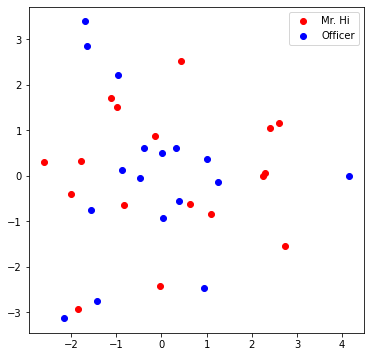

In [ ]:
def visualize_emb(emb):

  X = emb.weight.data.numpy()
  pca = PCA(n_components=2)
  components = pca.fit_transform(X)
  plt.figure(figsize=(6, 6))

  club1_x = []
  club1_y = []
  club2_x = []
  club2_y = []

  for node in G.nodes(data=True):

    if node[1]['club'] == 'Mr. Hi':
      club1_x.append(components[node[0]][0])
      club1_y.append(components[node[0]][1])

    else:
      club2_x.append(components[node[0]][0])
      club2_y.append(components[node[0]][1])

  plt.scatter(club1_x, club1_y, color="red", label="Mr. Hi")
  plt.scatter(club2_x, club2_y, color="blue", label="Officer")
  plt.legend()
  plt.show()

# Visualize the initial random embeddding
visualize_emb(emb)

In [ ]:
from torch.optim import SGD

def accuracy(pred, label):

  accu = 0.0
  accu = (torch.round(pred) == label).sum() / label.size(0)
  accu = round(accu.item(), 4)

  return accu

def train(emb, loss_fn, sigmoid, train_label, train_edge):

  # Implementing:
  # (1) Get the embeddings of the nodes in train_edge
  # (2) Dot product the embeddings between each node pair
  # (3) Feed the dot product result into sigmoid
  # (4) Feed the sigmoid output into the loss_fn
  # (5) Print both loss and accuracy of each epoch
  # (as a sanity check, the loss should decrease during training)

  epochs = 500
  learning_rate = 0.1

  optimizer = SGD(emb.parameters(), lr=learning_rate, momentum=0.9)

  for i in range(epochs):

    optimizer.zero_grad()

    u, v = train_edge[0], train_edge[1]
    pred = sigmoid(torch.bmm(emb(u).unsqueeze(1), emb(v).unsqueeze(2)).squeeze())
    loss = loss_fn(pred, train_label)

    loss.backward()
    optimizer.step()

    print(
      f"[Epoch {i:4d}]\t"
      f"acc: {accuracy(pred, train_label): .4f}\t"
      f"loss: {loss.item(): .6f}"
    )

loss_fn = nn.BCELoss()
sigmoid = nn.Sigmoid()

# Generate the positive and negative labels
pos_label = torch.ones(pos_edge_index.shape[1], )
neg_label = torch.zeros(neg_edge_index.shape[1], )

# Concat positive and negative labels into one tensor
train_label = torch.cat([pos_label, neg_label], dim=0)

# Concat positive and negative edges into one tensor
# Since the network is very small, we do not split the edges into val/test sets
train_edge = torch.cat([pos_edge_index, neg_edge_index], dim=1)

train(emb, loss_fn, sigmoid, train_label, train_edge)

[Epoch    0]	acc:  0.4872	loss:  2.026413
[Epoch    1]	acc:  0.4872	loss:  2.014800
[Epoch    2]	acc:  0.4872	loss:  1.992889
[Epoch    3]	acc:  0.4872	loss:  1.961978
[Epoch    4]	acc:  0.5000	loss:  1.923416
[Epoch    5]	acc:  0.5064	loss:  1.878418
[Epoch    6]	acc:  0.5064	loss:  1.828214
[Epoch    7]	acc:  0.5128	loss:  1.773966
[Epoch    8]	acc:  0.5192	loss:  1.716723
[Epoch    9]	acc:  0.5192	loss:  1.657489
[Epoch   10]	acc:  0.5256	loss:  1.597157
[Epoch   11]	acc:  0.5256	loss:  1.536514
[Epoch   12]	acc:  0.5256	loss:  1.476213
[Epoch   13]	acc:  0.5385	loss:  1.416785
[Epoch   14]	acc:  0.5449	loss:  1.358637
[Epoch   15]	acc:  0.5769	loss:  1.302056
[Epoch   16]	acc:  0.5962	loss:  1.247234
[Epoch   17]	acc:  0.6218	loss:  1.194282
[Epoch   18]	acc:  0.6410	loss:  1.143253
[Epoch   19]	acc:  0.6538	loss:  1.094155
[Epoch   20]	acc:  0.6538	loss:  1.046968
[Epoch   21]	acc:  0.6474	loss:  1.001652
[Epoch   22]	acc:  0.6538	loss:  0.958157
[Epoch   23]	acc:  0.6603	loss:  0

## Visualize the final node embeddings
Visualize your final embedding here!
You can visually compare the figure with the previous embedding figure.
After training, you should oberserve that the two classes are more evidently separated.
This is a great sanitity check for your implementation as well.

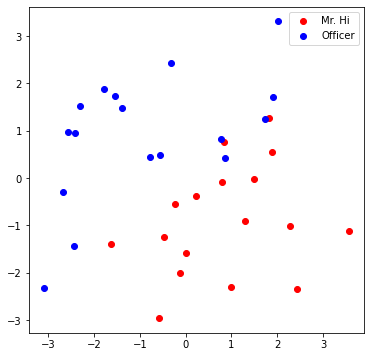

In [ ]:
# Visualize the final learned embedding
visualize_emb(emb)